# Welcome to Colab!

In [88]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os

os.listdir(path)


['chest_xray']

In [ ]:
os.listdir(os.path.join(path, "chest_xray"))


['chest_xray', '__MACOSX', 'val', 'test', 'train']

In [ ]:
import os

base_dir = path + "/chest_xray"

train_dir = base_dir + "/train"
test_dir  = base_dir + "/test"
val_dir   = base_dir + "/val"


In [ ]:
os.listdir(train_dir)


['PNEUMONIA', 'NORMAL']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history=model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 634ms/step - accuracy: 0.6923 - loss: 0.7985 - val_accuracy: 0.7404 - val_loss: 0.5203
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 489ms/step - accuracy: 0.8640 - loss: 0.3329 - val_accuracy: 0.7821 - val_loss: 0.5426
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9013 - loss: 0.2899 - val_accuracy: 0.8221 - val_loss: 0.4893
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 464ms/step - accuracy: 0.9083 - loss: 0.2836 - val_accuracy: 0.7917 - val_loss: 0.6518
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 465ms/step - accuracy: 0.9144 - loss: 0.2604 - val_accuracy: 0.8253 - val_loss: 0.4593


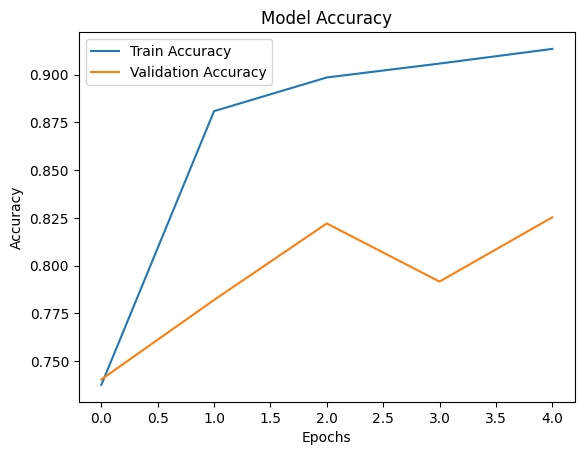

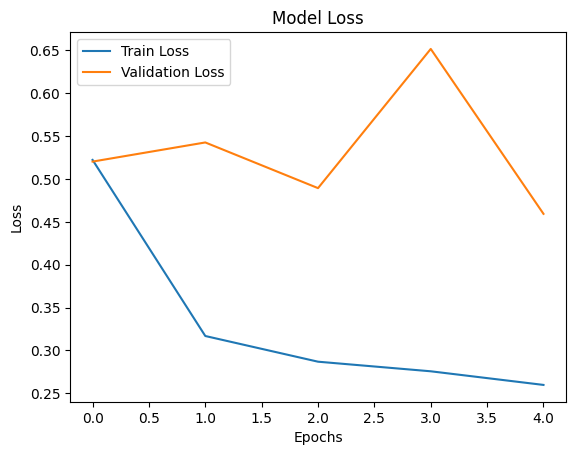

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    test_dir + "/NORMAL/IM-0001-0001.jpeg",
    target_size=(150,150)
)
img = image.img_to_array(img) / 255
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step


In [ ]:
if prediction[0][0] > 0.5:
    print("Pneumonia Detected")
else:
    print("Normal")


Normal


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os


In [ ]:
def check_blur(img_gray, threshold=100):
    blur_score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    return blur_score, blur_score < threshold


In [ ]:
def check_contrast(img_gray, threshold=40):
    contrast = img_gray.std()
    return contrast, contrast < threshold


In [ ]:
pneumonia_images = os.listdir(test_dir + "/PNEUMONIA")
img_path = os.path.join(test_dir, "PNEUMONIA", pneumonia_images[0])

print("Testing Image:", img_path)


Testing Image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg


In [ ]:
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


In [ ]:
# Load image using OpenCV
img_cv = cv2.imread(img_path)
img_gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

blur_score, is_blurry = check_blur(img_gray)
contrast_score, is_low_contrast = check_contrast(img_gray)


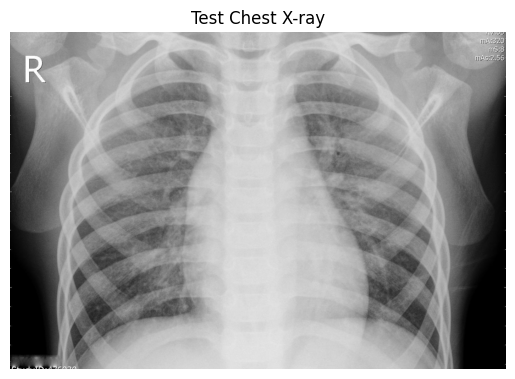

In [ ]:
plt.imshow(image.load_img(img_path))
plt.axis("off")
plt.title("Test Chest X-ray")
plt.show()


In [ ]:
prediction = model.predict(img_array)[0][0]

print(f"Prediction Probability: {prediction:.2f}")
print(f"Blur Score: {blur_score:.2f}")
print(f"Contrast Score: {contrast_score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction Probability: 0.98
Blur Score: 271.40
Contrast Score: 59.32


In [ ]:
# Image quality warning
if is_blurry or is_low_contrast:
    print("⚠ WARNING: Poor image quality. Prediction may be unreliable.")

# Confidence-aware diagnosis
if prediction > 0.8:
    print("🫁 Pneumonia Detected (High Confidence)")
elif prediction > 0.6:
    print("🟡 Pneumonia Detected (Low Confidence – Doctor Review Recommended)")
elif prediction > 0.4:
    print("🟡 Uncertain Case – Further Medical Tests Needed")
else:
    print("✅ Normal (High Confidence)")


🫁 Pneumonia Detected (High Confidence)


In [89]:
!ls


README.md


In [92]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/


Mounted at /content/drive
 1000069724-removebg.png     IMG_20240830_224233.jpg
'1000069763 (635×885)'	     IMG-20241208-WA0014.jpg
'1000069763 (635×885) (1)'   IMG-20250322-WA0027.jpg
'1000208751 (1).pdf'	     IMG_20250429_165057~2.jpg
 1735881518904.jpg	    'resume (1).pdf'
 Classroom		     resume.pdf
'Colab Notebooks'	     shristi__Copy_.pdf
 IMG_20230303_000357.jpg    'Shristi Dixit ECE .jpg'
 IMG-20230501-WA0010.jpg     Shristi_Dixit_Resume-1.pdf
 IMG-20240720-WA0002.jpg    'Unit test'


In [93]:
%cd /content/drive/MyDrive/Colab\ Notebooks
!ls


/content/drive/MyDrive/Colab Notebooks
 MyProject   Myproject1  'MyProject (1)'   Untitled0.ipynb


In [96]:
!mkdir /content/drive/MyDrive/Myproject1
!cp "/content/drive/MyDrive/Colab\ Notebooks/YourNotebook.ipynb" /content/drive/MyDrive/MyProject/



mkdir: cannot create directory ‘/content/drive/MyDrive/Myproject1’: File exists
cp: cannot stat '/content/drive/MyDrive/Colab\ Notebooks/YourNotebook.ipynb': No such file or directory


In [97]:
!ls "/content/drive/MyDrive/Colab Notebooks"


 MyProject   Myproject1  'MyProject (1)'   Untitled0.ipynb


In [99]:
!cp "/content/drive/MyDrive/Colab Notebooks/*.ipynb" "/content/drive/MyDrive/Myproject1/"


cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/*.ipynb': No such file or directory


In [100]:
%cd "/content/drive/MyDrive/Myproject1"
!ls


/content/drive/MyDrive/Myproject1


In [101]:
!find /content/drive/MyDrive/ -name "*.ipynb"


/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb


In [102]:
!cp "/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb" "/content/drive/MyDrive/Myproject1/"

In [103]:
%cd "/content/drive/MyDrive/Myproject1"
!ls

/content/drive/MyDrive/Myproject1
Untitled0.ipynb


In [104]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Myproject1/.git/


In [105]:
!git config --global user.name "dshristi2525"
!git config --global user.email "shristidixit10043c@gmail.com"


In [106]:
!git remote add origin https://github.com/dshristi2525/pneumonia_detection

In [107]:
!git pull origin main --allow-unrelated-histories

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.25 KiB | 37.00 KiB/s, done.
From https://github.com/dshristi2525/pneumonia_detection
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main


In [110]:
import shutil

# Create project folder if it doesn't exist
!mkdir -p "/content/drive/MyDrive/Myproject1"

# Copy the dataset from Kaggle input to your Drive
shutil.copytree("/kaggle/input/chest-xray-pneumonia",
                "/content/drive/MyDrive/Myproject1/chest-xray-pneumonia")


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/Myproject1/chest-xray-pneumonia'

In [ ]:
%cd "/content/drive/MyDrive/Myproject1/chest-xray-pneumonia/chest_xray"
!ls


In [ ]:
import shutil
import os

project_folder = "/content/drive/MyDrive/Myproject1/chest-xray-pneumonia"

# Remove the existing folder
if os.path.exists(project_folder):
    shutil.rmtree(project_folder)

# Copy from Kaggle input
shutil.copytree("/kaggle/input/chest-xray-pneumonia", project_folder)


In [ ]:
import zipfile

dataset_zip = "/content/drive/MyDrive/Myproject1/chest-xray-pneumonia.zip"
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/Myproject1/chest-xray-pneumonia")


In [ ]:
from google.colab import files

# Save notebook to Drive
!cp "/content/your_notebook_name.ipynb" "/content/drive/MyDrive/Myproject1/"


In [ ]:
%cd "/content/drive/MyDrive/Myproject1"
!ls
